# <span style="color:black; font-weight:bold;">Spatial ATAC-RNA mouse brain Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 03.16.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 03.16.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Spatial ATAC-RNA mouse brain is available at [ATAC-RNA](https://drive.google.com/file/d/1AYCrhDIFlZCVfQ1s3BJLMgcsci0eMUTT/view?usp=drive_link)  
In this tutorial we apply SpaLP to 5 Simulated multi-omics datasets from [Spatial ATAC-RNA-seq](https://doi.org/10.1038/s41586-023-05795-1)

In [1]:
from SpaLP.utils import prepare_inputs, set_seed,create_new_color_dict,Graph
from SpaLP.LP import SpatialLocalPooling
import torch
import warnings
import scanpy as sc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

In [4]:
def pca(adata, use_reps=None, n_comps=10):
    
    """Dimension reduction with PCA algorithm"""
    from sklearn.decomposition import PCA
    from scipy.sparse.csc import csc_matrix
    from scipy.sparse.csr import csr_matrix
    pca = PCA(n_components=n_comps,random_state=42)
    if use_reps is not None:
       feat_pca = pca.fit_transform(adata.obsm[use_reps])
    else: 
       if isinstance(adata.X, csc_matrix) or isinstance(adata.X, csr_matrix):
          feat_pca = pca.fit_transform(adata.X.toarray()) 
       else:   
          feat_pca = pca.fit_transform(adata.X)
    return feat_pca

## <span style="color:black; font-weight:bold;">Loading spatial-ATAC-RNA-seq mouse brain data</span>

In [5]:
%%time
adata1=sc.read_h5ad('/home/dbj/mouse/SpatialGlue/Mouse_Brain/adata_RNA.h5ad')
adata2=sc.read_h5ad('/home/dbj/mouse/SpatialGlue/Mouse_Brain/adata_peaks_normalized.h5ad')
adata1.var_names_make_unique()
adata2.var_names_make_unique()
sc.pp.filter_genes(adata1, min_cells=10)
sc.pp.filter_cells(adata1, min_genes=200)

sc.pp.highly_variable_genes(adata1, flavor="seurat_v3", n_top_genes=3000)
adata1 =  adata1[:, adata1.var['highly_variable']]
sc.pp.normalize_total(adata1, target_sum=1e4)
sc.pp.log1p(adata1)
sc.pp.scale(adata1)
adata1.obsm['feat'] = pca(adata1, n_comps=50)

adata2 = adata2[adata1.obs_names].copy()
if 'X_lsi' not in adata2.obsm.keys():
    sc.pp.highly_variable_genes(adata2, flavor="seurat_v3", n_top_genes=3000)
    lsi(adata2, use_highly_variable=False, n_components=51)
adata2.obsm['feat'] = adata2.obsm['X_lsi'].copy()

CPU times: user 11 s, sys: 19.5 s, total: 30.5 s
Wall time: 5.95 s


## <span style="color:black; font-weight:bold;">Data preprocessing</span>
We use [scanpy](https://scanpy.readthedocs.io/en/stable/installation.html) package to perform standard data processing.  
The standard processed expression matrix was saved in adata.obsm[<span style="color:red;">'feat'</span>] and used as input to the model.

In [6]:
adata=sc.AnnData(np.hstack([adata1.obsm['feat'],adata2.obsm['feat']]))
adata.obs_names=adata1.obs_names
adata.obs['truth']=adata1.obs['truth']
sc.pp.scale(adata)
adata.obsm['spatial']=adata2.obsm['spatial']
adata.obsm['feat']=adata.X

## <span style="color:black; font-weight:bold;">Compute Spatial Neighbor Graph and build the neighbor index matrix</span>
We compute the spatial Graph using 18 neighbors in spatial ATAC-RNA-seq data. k=18

In [7]:
%%time
graph = prepare_inputs(adata, k=18, device=device)

CPU times: user 1.43 s, sys: 366 ms, total: 1.8 s
Wall time: 762 ms


### <span style="color:black; font-weight:bold;">Initialize the SpaLP model</span>

In [8]:
model = SpatialLocalPooling(in_channels=adata.obsm['feat'].shape[1], out_channels=25)

### <span style="color:black; font-weight:bold;">Model training (mode='single-slice')</span>
epochs:training epochs (400)  
lr:Learning rate (Default:1e-3)     
device:Model training device    
seed:Random seed (Default:7)  
mode:single-slice/multi-slices

In [9]:
model.Train(graph=graph,epochs=400,lr=1e-3,device=device,seed=7,mode='single-slice')

Training(single-slices): 100%|███████████████████████████████████████| 400/400 [00:02<00:00, 162.46it/s, Epoch=399, Loss=0.9142, PeakGPUmemory=0.26GB]


### <span style="color:black; font-weight:bold;">Output the reconstructed expression matrix and embedding (mode='single-slice')</span>

In [10]:
reconstructed, embedding = model.get_embedding(graph,mode='single-slice')
adata.obsm['SpaLP']=embedding

### <span style="color:black; font-weight:bold;">Downstream analysis (KMeans)</span>

In [11]:
%%time
from sklearn.cluster import KMeans
# KMeans 
kmeans = KMeans(n_clusters=18, random_state=2024) 
labels = kmeans.fit_predict(adata.obsm['SpaLP'])
adata.obs['SpaLP']=labels.astype(str)

CPU times: user 2.91 s, sys: 6.76 s, total: 9.67 s
Wall time: 218 ms


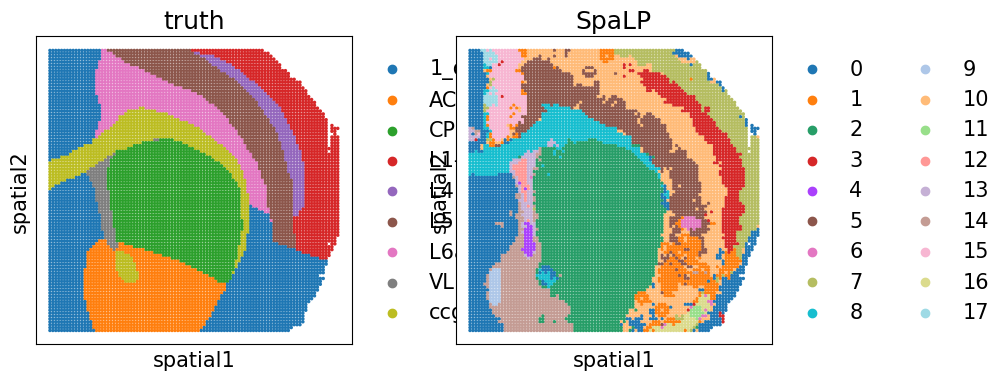

In [14]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['font.size'] = 15

sc.pl.embedding(adata,basis='spatial',color=['truth','SpaLP'],size=25)

### <span style="color:black; font-weight:bold;">Clustering metrics</span>

In [13]:
import numpy as np
from sklearn.metrics import (homogeneity_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score,fowlkes_mallows_score)

true_labels = np.array(adata.obs['truth'])
cluster_labels = np.array(adata.obs['SpaLP'])

FMI = fowlkes_mallows_score(true_labels, cluster_labels)
homogeneity = homogeneity_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("ARI:", ari)
print("NMI:", nmi)
print("AMI:", ami)
print("FMI:", FMI)
print("V-Measure:", v_measure)
print("Homogeneity:", homogeneity)

ARI: 0.4343564511758007
NMI: 0.5691927589659812
AMI: 0.567651980829332
FMI: 0.5160884848823772
V-Measure: 0.5691927589659814
Homogeneity: 0.6122170128724014
